# MakeMore — Part 2: MLP Language Model

**Based on:** Andrej Karpathy's "Building makemore Part 2: MLP"  
**Reference paper:** Bengio et al. (2003) — *A Neural Probabilistic Language Model*

## Overview

We upgrade from the bigram model to a proper **Multi-Layer Perceptron (MLP)** following Bengio et al. (2003).  
The key improvements are:

1. **Character embeddings** — each character maps to a learned dense vector instead of a one-hot vector.
2. **Context window** — previous `block_size` characters are used to predict the next one (vs. only 1).
3. **Hidden layer** — a `tanh` nonlinearity gives the model representational power.
4. **Minibatch SGD** — randomly sample batches for efficient training.
5. **Train / Dev / Test splits** — proper evaluation to detect overfitting.

**MLflow** tracks every training experiment including loss curves, hyperparameters, and generated samples.

---

## 1. Setup

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import mlflow

%matplotlib inline

SEED = 2147483647

print(f"PyTorch version : {torch.__version__}")
print(f"MLflow  version : {mlflow.__version__}")

c:\Users\borut\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.11.0+cpu
MLflow  version : 3.10.1


In [2]:
# ── Device Setup ──────────────────────────────────────────────────────────────
# Automatically use GPU if available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cpu


In [3]:
EXPERIMENT_NAME = "makemore-part2-mlp"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: '{EXPERIMENT_NAME}'")

2026/04/25 07:30:41 INFO mlflow.tracking.fluent: Experiment with name 'makemore-part2-mlp' does not exist. Creating a new experiment.


MLflow experiment: 'makemore-part2-mlp'


## 2. Data Loading & Vocabulary

In [4]:
with open('../data/names.txt', 'r') as f:
    words = f.read().splitlines()

print(f"Total words  : {len(words):,}")
print(f"Sample names : {words[:8]}")

Total words  : 32,033
Sample names : ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [5]:
# Vocabulary — '.' is the start/end token at index 0
chars = sorted(set(''.join(words)))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
VOCAB_SIZE = len(itos)   # 27

print(f"Vocabulary size: {VOCAB_SIZE}")

Vocabulary size: 27


## 3. Dataset Construction

For each character in a word, we slide a window of size `block_size` over the preceding characters to form `(X, Y)` pairs.

```
example word:  e  m  m  a  .    (with '.' as both start padding and end token)

context → target
... → e
..e → m
.em → m
emm → a
mma → .
```

We split the dataset into **80% train / 10% dev / 10% test**.

In [6]:
def build_dataset(words: list[str], block_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Build (X, Y) tensors for a language-modelling task.

    X[i] is a context of `block_size` character indices.
    Y[i] is the index of the character that follows that context.
    """
    X, Y = [], []
    for word in words:
        context = [0] * block_size            # start with '.' padding
        for ch in word + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]      # slide the window forward
    return torch.tensor(X), torch.tensor(Y)

In [7]:
BLOCK_SIZE = 3    # context window length

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

# Build splits and move all tensors to the GPU
Xtr,  Ytr  = [t.to(device) for t in build_dataset(words[:n1],   BLOCK_SIZE)]  # 80 % train
Xdev, Ydev = [t.to(device) for t in build_dataset(words[n1:n2], BLOCK_SIZE)]  # 10 % dev
Xte,  Yte  = [t.to(device) for t in build_dataset(words[n2:],   BLOCK_SIZE)]  # 10 % test

print(f"Train examples : {Xtr.shape[0]:,}  (device: {Xtr.device})")
print(f"Dev   examples : {Xdev.shape[0]:,}")
print(f"Test  examples : {Xte.shape[0]:,}")


Train examples : 182,625  (device: cpu)
Dev   examples : 22,655
Test  examples : 22,866


---
## 4. MLP Architecture

```
Input: block_size character indices
  └── Embedding lookup C: (vocab_size, n_embd)
      └── Concatenate embeddings → shape (batch, block_size * n_embd)
          └── Linear W1 + b1 → tanh hidden layer: (batch, n_hidden)
              └── Linear W2 + b2 → logits: (batch, vocab_size)
                  └── Cross-entropy loss
```

### 4.1 Initialize Parameters

In [8]:
def init_mlp(
    vocab_size: int,
    block_size: int,
    n_embd: int,
    n_hidden: int,
    seed: int = SEED,
    device: torch.device = torch.device("cpu"),
) -> list[torch.Tensor]:
    """Initialize and return all learnable parameters of the MLP on `device`.

    Returns [C, W1, b1, W2, b2], each with requires_grad=True.
    """
    g = torch.Generator(device="cpu").manual_seed(seed)

    C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
    W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device) * 0.2
    b1 = torch.randn(n_hidden,                        generator=g).to(device) * 0.01
    W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device) * 0.01
    b2 = torch.zeros(vocab_size,                                    device=device)

    parameters = [C, W1, b1, W2, b2]
    for p in parameters:
        p.requires_grad = True

    total_params = sum(p.nelement() for p in parameters)
    print(f"Total parameters : {total_params:,}  (device: {device})")
    return parameters


### 4.2 Forward Pass

In [9]:
def forward(
    X_batch: torch.Tensor,
    parameters: list[torch.Tensor],
) -> tuple[torch.Tensor, torch.Tensor]:
    """Run a forward pass through the MLP.

    Returns (logits, h) where h is the tanh hidden activations.
    """
    C, W1, b1, W2, b2 = parameters

    emb    = C[X_batch]                              # (B, block_size, n_embd)
    emb_cat = emb.view(emb.shape[0], -1)             # (B, block_size * n_embd) — concatenate
    h      = torch.tanh(emb_cat @ W1 + b1)          # (B, n_hidden)
    logits = h @ W2 + b2                             # (B, vocab_size)
    return logits, h

### 4.3 Evaluation Helper

In [10]:
@torch.no_grad()
def evaluate_split(
    X: torch.Tensor,
    Y: torch.Tensor,
    parameters: list[torch.Tensor],
) -> float:
    """Compute cross-entropy loss on a full dataset split (no gradient)."""
    logits, _ = forward(X, parameters)
    return F.cross_entropy(logits, Y).item()

---
## 5. Training with MLflow Tracking

### Learning Rate Schedule

We use a **step-decay schedule**: a higher LR early on for fast convergence, then a lower LR for fine-tuning.  
This is a simple but effective technique — the loss often improves noticeably in the second phase.

In [11]:
def train_mlp(
    Xtr: torch.Tensor,
    Ytr: torch.Tensor,
    Xdev: torch.Tensor,
    Ydev: torch.Tensor,
    parameters: list[torch.Tensor],
    num_steps: int     = 200_000,
    batch_size: int    = 32,
    lr_high: float     = 0.1,
    lr_low: float      = 0.01,
    lr_decay_step: int = 100_000,
    log_every: int     = 1_000,
    seed: int          = SEED,
) -> dict:
    """Train the MLP and return a dict with training history.
    All tensors (Xtr, Ytr, parameters) must already be on the target device.
    The random generator is kept on CPU (required by PyTorch).
    """
    g = torch.Generator(device="cpu").manual_seed(seed)
    train_losses, dev_losses, steps_logged = [], [], []

    for step in range(1, num_steps + 1):
        # ── Minibatch sampling ────────────────────────────────────────────────
        idx = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

        # ── Forward pass ──────────────────────────────────────────────────────
        logits, _ = forward(Xtr[idx], parameters)
        loss      = F.cross_entropy(logits, Ytr[idx])

        # ── Backward pass ─────────────────────────────────────────────────────
        for p in parameters:
            p.grad = None
        loss.backward()

        # ── Learning rate schedule (step decay) ───────────────────────────────
        lr = lr_high if step < lr_decay_step else lr_low
        with torch.no_grad():
            for p in parameters:
                p.data -= lr * p.grad

        # ── Periodic evaluation ───────────────────────────────────────────────
        if step % log_every == 0 or step == 1:
            dev_loss = evaluate_split(Xdev, Ydev, parameters)
            train_losses.append(loss.item())
            dev_losses.append(dev_loss)
            steps_logged.append(step)

    return {"steps": steps_logged, "train_loss": train_losses, "dev_loss": dev_losses}


In [12]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EMBD     = 10      # embedding dimension per character
N_HIDDEN   = 200     # neurons in the hidden layer
NUM_STEPS  = 200_000
BATCH_SIZE = 32
LR_HIGH    = 0.1
LR_LOW     = 0.01
LR_DECAY   = 100_000

# ── Initialize model — all weights placed on the GPU ─────────────────────────
parameters = init_mlp(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_hidden=N_HIDDEN,
    device=device,
)


Total parameters : 11,897  (device: cpu)


Train loss : 2.0366
Dev   loss : 2.1043
Test  loss : 2.1009
Device     : cpu


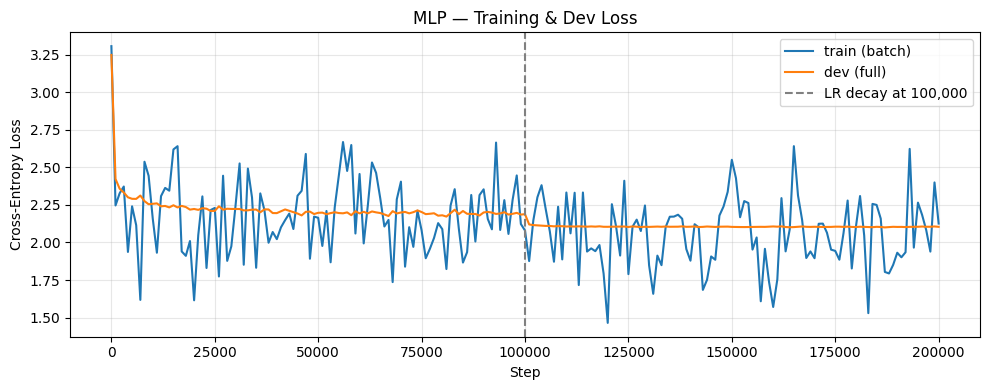

In [13]:
# ── Train with MLflow tracking ────────────────────────────────────────────────
with mlflow.start_run(run_name="mlp-baseline"):

    # — Log hyperparameters (including device) —
    mlflow.log_params({
        "model"         : "mlp",
        "block_size"    : BLOCK_SIZE,
        "n_embd"        : N_EMBD,
        "n_hidden"      : N_HIDDEN,
        "num_steps"     : NUM_STEPS,
        "batch_size"    : BATCH_SIZE,
        "lr_high"       : LR_HIGH,
        "lr_low"        : LR_LOW,
        "lr_decay_step" : LR_DECAY,
        "seed"          : SEED,
        "device"        : str(device),
        "total_params"  : sum(p.nelement() for p in parameters),
    })

    # — Train (all tensors on GPU) —
    history = train_mlp(
        Xtr, Ytr, Xdev, Ydev,
        parameters,
        num_steps=NUM_STEPS,
        batch_size=BATCH_SIZE,
        lr_high=LR_HIGH,
        lr_low=LR_LOW,
        lr_decay_step=LR_DECAY,
    )

    # — Log per-step metrics —
    for step, tl, dl in zip(history["steps"], history["train_loss"], history["dev_loss"]):
        mlflow.log_metric("train_loss", tl, step=step)
        mlflow.log_metric("dev_loss",   dl, step=step)

    # — Evaluate on all splits —
    final_train = evaluate_split(Xtr,  Ytr,  parameters)
    final_dev   = evaluate_split(Xdev, Ydev, parameters)
    final_test  = evaluate_split(Xte,  Yte,  parameters)

    mlflow.log_metrics({
        "final_train_loss": final_train,
        "final_dev_loss"  : final_dev,
        "final_test_loss" : final_test,
    })

    print(f"Train loss : {final_train:.4f}")
    print(f"Dev   loss : {final_dev:.4f}")
    print(f"Test  loss : {final_test:.4f}")
    print(f"Device     : {device}")

    # — Plot loss curves and log as artifact —
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history["steps"], history["train_loss"], label="train (batch)")
    ax.plot(history["steps"], history["dev_loss"],   label="dev (full)")
    ax.axvline(LR_DECAY, color='gray', linestyle='--', label=f'LR decay at {LR_DECAY:,}')
    ax.set_xlabel("Step")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title("MLP — Training & Dev Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("mlp_loss_curve.png", dpi=100)
    mlflow.log_artifact("mlp_loss_curve.png")
    plt.show()


---
## 6. Sampling Generated Names

We autoregressively sample from the trained MLP: start with `block_size` padding tokens, then predict one character at a time, shifting the context window forward until we generate a `'.'` (end token).

In [14]:
@torch.no_grad()
def sample_from_mlp(
    parameters: list[torch.Tensor],
    block_size: int,
    itos: dict,
    num_samples: int = 20,
    seed: int        = SEED + 10,
) -> list[str]:
    """Autoregressively sample names from the trained MLP.
    Parameters are moved to CPU so that torch.multinomial works with a seeded Generator.
    """
    g = torch.Generator().manual_seed(seed)
    # Move all params to CPU for seeded sampling
    cpu_params = [p.detach().cpu() for p in parameters]
    samples = []

    for _ in range(num_samples):
        out     = []
        context = [0] * block_size
        while True:
            X_in        = torch.tensor([context])        # (1, block_size) on CPU
            logits, _   = forward(X_in, cpu_params)
            probs       = F.softmax(logits, dim=1)
            ix          = torch.multinomial(probs, num_samples=1, generator=g).item()
            context     = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])
        samples.append(''.join(out))

    return samples


generated = sample_from_mlp(parameters, BLOCK_SIZE, itos, num_samples=20)
print("Generated names (MLP model):")
for name in generated:
    print(f"  {name}")


Generated names (MLP model):
  carmah
  amelle
  khi
  mili
  thold
  kanden
  jazonte
  deliah
  jareei
  nellara
  chaiir
  kaleigh
  ham
  por
  dessanis
  lilea
  jadiquinterridearynix
  kaellissa
  mel
  edi


---
## 7. Visualizing Character Embeddings

Plot the 2D projection of the learned embedding for each character.  
If `n_embd > 2`, we take only the first two dimensions for visualization.

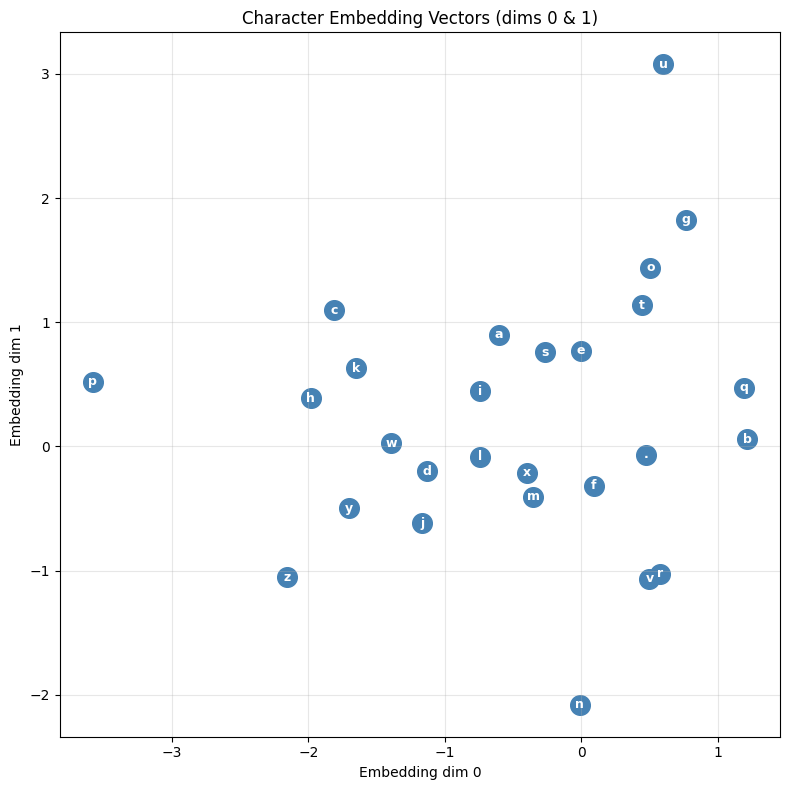

In [15]:
C = parameters[0].detach().cpu()   # move embedding table to CPU for matplotlib

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(C[:, 0], C[:, 1], s=200, color='steelblue')
for i in range(C.shape[0]):
    ax.text(C[i, 0].item(), C[i, 1].item(), itos[i],
            ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.set_title("Character Embedding Vectors (dims 0 & 1)")
ax.set_xlabel("Embedding dim 0")
ax.set_ylabel("Embedding dim 1")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mlp_embeddings.png", dpi=100)
plt.show()


---
## 8. Hyperparameter Sweep with MLflow

We compare different **embedding sizes** and **hidden layer sizes** to find a good model capacity vs. training time trade-off.

In [16]:
sweep_configs = [
    {"n_embd":  2, "n_hidden": 100, "num_steps": 100_000},
    {"n_embd":  5, "n_hidden": 100, "num_steps": 100_000},
    {"n_embd": 10, "n_hidden": 100, "num_steps": 100_000},
    {"n_embd": 10, "n_hidden": 200, "num_steps": 100_000},
    {"n_embd": 10, "n_hidden": 300, "num_steps": 100_000},
]

sweep_results = []

for cfg in sweep_configs:
    run_name = f"embd={cfg['n_embd']}_hid={cfg['n_hidden']}"
    with mlflow.start_run(run_name=run_name):

        # Initialize model weights on the GPU
        params = init_mlp(
            vocab_size=VOCAB_SIZE,
            block_size=BLOCK_SIZE,
            n_embd=cfg["n_embd"],
            n_hidden=cfg["n_hidden"],
            device=device,
        )

        mlflow.log_params({
            "model"         : "mlp",
            "block_size"    : BLOCK_SIZE,
            "n_embd"        : cfg["n_embd"],
            "n_hidden"      : cfg["n_hidden"],
            "num_steps"     : cfg["num_steps"],
            "batch_size"    : BATCH_SIZE,
            "lr_high"       : LR_HIGH,
            "lr_low"        : LR_LOW,
            "lr_decay_step" : LR_DECAY // 2,
            "device"        : str(device),
            "total_params"  : sum(p.nelement() for p in params),
        })

        history = train_mlp(
            Xtr, Ytr, Xdev, Ydev, params,
            num_steps=cfg["num_steps"],
            batch_size=BATCH_SIZE,
            lr_high=LR_HIGH,
            lr_low=LR_LOW,
            lr_decay_step=LR_DECAY // 2,
        )

        for step, tl, dl in zip(history["steps"], history["train_loss"], history["dev_loss"]):
            mlflow.log_metric("train_loss", tl, step=step)
            mlflow.log_metric("dev_loss",   dl, step=step)

        final_dev = evaluate_split(Xdev, Ydev, params)
        mlflow.log_metric("final_dev_loss", final_dev)
        sweep_results.append({**cfg, "dev_loss": final_dev})

    print(f"{run_name:<35} dev_loss = {final_dev:.4f}")

print("\nBest configuration:")
best = min(sweep_results, key=lambda r: r["dev_loss"])
print(best)


Total parameters : 3,481  (device: cpu)
embd=2_hid=100                      dev_loss = 2.2464
Total parameters : 4,462  (device: cpu)
embd=5_hid=100                      dev_loss = 2.1702
Total parameters : 6,097  (device: cpu)
embd=10_hid=100                     dev_loss = 2.1407
Total parameters : 11,897  (device: cpu)
embd=10_hid=200                     dev_loss = 2.1133
Total parameters : 17,697  (device: cpu)
embd=10_hid=300                     dev_loss = 2.1036

Best configuration:
{'n_embd': 10, 'n_hidden': 300, 'num_steps': 100000, 'dev_loss': 2.1036365032196045}


In [17]:
import os
import torch
from datetime import datetime

os.makedirs('weights', exist_ok=True)

# Unpack all 5 parameters from the trained model
C, W1, b1, W2, b2 = parameters

checkpoint = {
    "model_state": {
        "C":  C.data,    # Embedding table  — shape (vocab_size, n_embd)
        "W1": W1.data,   # Hidden layer weights — shape (n_embd * block_size, n_hidden)
        "b1": b1.data,   # Hidden layer biases  — shape (n_hidden,)
        "W2": W2.data,   # Output layer weights — shape (n_hidden, vocab_size)
        "b2": b2.data,   # Output layer biases  — shape (vocab_size,)
    },
    "config": {
        "vocab_size":  VOCAB_SIZE,
        "block_size":  BLOCK_SIZE,
        "n_embd":      N_EMBD,
        "n_hidden":    N_HIDDEN,
    },
    "metadata": {
        "train_loss": final_train,
        "dev_loss":   final_dev,
        "test_loss":  final_test,
        "trained_by": "Palden",
        "date":       datetime.now().isoformat(),
    }
}

torch.save(checkpoint, "weights/part2_mlp.pt")
print("Successfully saved checkpoint to weights/part2_mlp.pt")

Successfully saved checkpoint to weights/part2_mlp.pt


In [18]:
import torch

ckpt = torch.load("weights/part2_mlp.pt", weights_only=False)

# Restore weights
C  = ckpt["model_state"]["C"]
W1 = ckpt["model_state"]["W1"]
b1 = ckpt["model_state"]["b1"]
W2 = ckpt["model_state"]["W2"]
b2 = ckpt["model_state"]["b2"]

print("=== Config ===")
for k, v in ckpt["config"].items():
    print(f"  {k}: {v}")

print("\n=== Metadata ===")
for k, v in ckpt["metadata"].items():
    print(f"  {k}: {v}")

print("\n=== Weight Shapes ===")
print(f"  C  : {C.shape}")
print(f"  W1 : {W1.shape}")
print(f"  b1 : {b1.shape}")
print(f"  W2 : {W2.shape}")
print(f"  b2 : {b2.shape}")

=== Config ===
  vocab_size: 27
  block_size: 3
  n_embd: 10
  n_hidden: 200

=== Metadata ===
  train_loss: 2.0365774631500244
  dev_loss: 2.1036365032196045
  test_loss: 2.100853443145752
  trained_by: Palden
  date: 2026-04-25T08:38:04.316699

=== Weight Shapes ===
  C  : torch.Size([27, 10])
  W1 : torch.Size([30, 200])
  b1 : torch.Size([200])
  W2 : torch.Size([200, 27])
  b2 : torch.Size([27])


---
## 9. Summary

| Concept | Key Takeaway |
|---|---|
| **Embedding table C** | Maps each character to a dense vector; learned end-to-end |
| **Context window** | Using the last `block_size` chars (vs. 1 in bigram) reduces loss significantly |
| **tanh hidden layer** | Adds nonlinearity; enables learning complex character patterns |
| **Cross-entropy loss** | Equivalent to NLL; numerically stable via `F.cross_entropy` |
| **Minibatch SGD** | Random mini-batches provide noisy but cheap gradient estimates |
| **LR decay schedule** | High LR to explore, low LR to converge — simple and effective |
| **Train / Dev / Test** | Dev loss guides hyperparameter choices; test loss is the final unbiased estimate |
| **MLflow** | Tracks every run: params, step-by-step metrics, artifacts |

**Next:** Part 3 — Activations, Gradients, and Batch Normalization.